## How this data was generated

```bash
cd camonitor-cliff/
python3 run_channel_cost_test.py --scenarios B,D,E --out-dir ../docs/camonitor-cliff/channel_cost_bd
```

Defaults used: `--n-servers 10 --pvs-per-server 500 --pvs-per-buffer 20 --round-interval-s 0.3
--extra-rounds 50` (10 servers × 500 PVs = 5,000 channels per scenario, 300 rounds total: 250 to
touch every buffer once, 50 more past the buffer-pool rollover) — same scale as the B-vs-C run in
`../channel_cost/results.ipynb`, for direct comparability. Client RSS (in addition to server RSS)
is polled by the orchestrator process itself, from the client subprocess's own PID -- the client
runs with `--no-watcher`, so there's no in-client `CacheWatcher` doing this.

# Channel cost — B vs D vs E

Loads the CSVs written by `run_channel_cost_test.py --scenarios B,D,E` (in `camonitor-cliff/`) and
compares three scenarios at real scale (5,000 channels, spread across 10 mock IOCs — see that
script's module docstring for why one server alone can't be pushed this far).

- **B** — `epics.PV(pvname, auto_monitor=False)`, channel left open (never cleared). Small,
  bounded server-side cost -- but leaves the full last-read *value* cached client-side
  (`epics.ca._cache[ctx][pvname].get_results`) forever, since `disconnect()` never touches it.
  Confirmed directly this session: ~24.5 KB/channel client-side at this same scale, matching one
  2800-element array almost exactly.
- **D** — plain `epics.caget(pvname)` (pyepics' default monitor stays subscribed), but the scan's
  own channels are cleared right after via the same scoped logic as
  `slac_timing.buffer.Buffer._clear_ca_cache()`. Costs much more server-side than B -- traced this
  session to `caproto`'s per-subscription backlog (`unexpired_updates`, `MAX_SUBSCRIPTION_BACKLOG
  = 1000`), which buffers real scan-driven monitor pushes for as long as each subscription stays
  open before D's scoped clear cancels it -- legitimate CA server behavior, not a caproto bug, so
  it plausibly reproduces on a real IOC too, not just this mock one.
- **E** — B, plus clearing *only* `entry.get_results` (the cached value) after each read, leaving
  the channel/connection itself untouched. Unlike C's `epics.ca.clear_channel()` (a different
  notebook), this doesn't touch the shared low-level channel other callers might depend on, so it
  doesn't carry C's shared-`chid` crash risk (see `claude/lazy-pv-clear-channel.md`'s danger
  analysis) -- the question this notebook answers is whether E keeps B's small server-side/speed
  profile while avoiding B's client-side value-cache growth.

See `../channel_cost/results.ipynb` for the earlier B-vs-C memory-only comparison and
`../../../camonitor-cliff/README.md` for the full write-up.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

HERE = Path.cwd()
LABEL_LIST = ["B", "D", "E"]
COLORS = {"B": "tab:orange", "D": "tab:purple", "E": "tab:green"}
LABELS = {
    "B": "B — auto_monitor=False, never cleared",
    "D": "D — caget() default (monitor on) + periodic scoped clear",
    "E": "E — B + clear client value cache",
}

In [2]:
mem = {
    label: pd.read_csv(HERE / f"results_{label}.csv")
    for label in LABEL_LIST
}
rounds = {
    label: pd.read_csv(HERE / f"round_times_{label}.csv")
    for label in LABEL_LIST
}
for label in LABEL_LIST:
    m, r = mem[label], rounds[label]
    print(label, "mem", m.shape, f"{m['elapsed_s'].iloc[0]:.1f}s -> {m['elapsed_s'].iloc[-1]:.1f}s",
          "| rounds", r.shape)

B mem (789, 4) 0.0s -> 789.1s | rounds (300, 4)
D mem (1148, 4) 0.0s -> 1148.2s | rounds (300, 4)
E mem (796, 4) 0.0s -> 796.2s | rounds (300, 4)


## Memory

In [3]:
def summarize_memory(label, df):
    # Settled baseline: server RSS jumps during the first ~1-2s of
    # asyncio/scan-callback warm-up, independent of any client channels.
    # Real plateau: the elapsed_s where channels_touched_so_far first
    # reaches its max (all channels touched), not assumed from configured
    # round timing (per-round time grows substantially with total channel
    # count already open at this scale).
    baseline = df[df["elapsed_s"] >= 2.0].iloc[0]
    total_channels = df["channels_touched_so_far"].max()
    plateau = df[df["channels_touched_so_far"] == total_channels].iloc[0]
    final = df.iloc[-1]
    server_delta = plateau["server_mem_rss_mb"] - baseline["server_mem_rss_mb"]
    client_delta = plateau["client_mem_rss_mb"] - baseline["client_mem_rss_mb"]
    server_kb = (server_delta / total_channels) * 1024 if total_channels else 0
    client_kb = (client_delta / total_channels) * 1024 if total_channels else 0
    return {
        "scenario": LABELS[label],
        "total_channels": int(total_channels),
        "server_baseline_mb": round(baseline["server_mem_rss_mb"], 1),
        "server_plateau_mb": round(plateau["server_mem_rss_mb"], 1),
        "server_delta_mb": round(server_delta, 2),
        "server_kb_per_channel": round(server_kb, 2),
        "client_baseline_mb": round(baseline["client_mem_rss_mb"], 1),
        "client_plateau_mb": round(plateau["client_mem_rss_mb"], 1),
        "client_delta_mb": round(client_delta, 2),
        "client_kb_per_channel": round(client_kb, 2),
    }

memory_summary = pd.DataFrame([summarize_memory(label, mem[label]) for label in LABEL_LIST]).set_index("scenario")
memory_summary

,total_channels,server_baseline_mb,server_plateau_mb,server_delta_mb,server_kb_per_channel,client_baseline_mb,client_plateau_mb,client_delta_mb,client_kb_per_channel
scenario,,,,,,,,,
"B — auto_monitor=False, never cleared",5000,1133.9,1144.4,10.49,2.15,39.2,158.9,119.71,24.52
D — caget() default (monitor on) + periodic scoped clear,5000,1136.8,1233.7,96.93,19.85,39.8,40.2,0.44,0.09
E — B + clear client value cache,5000,1133.9,1144.2,10.38,2.13,39.1,45.8,6.79,1.39


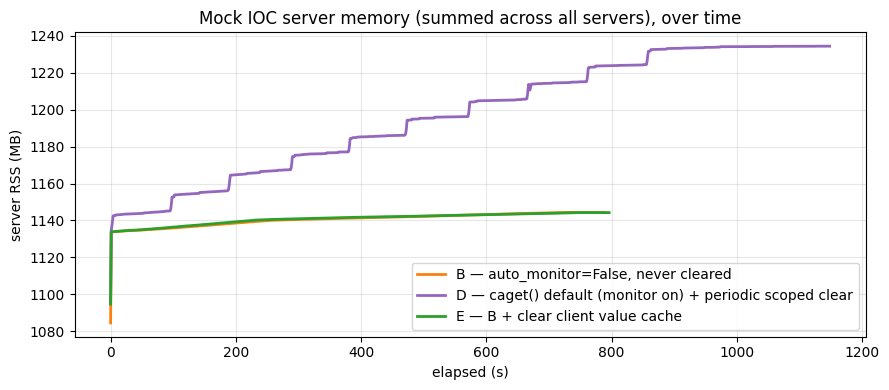

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for label in LABEL_LIST:
    df = mem[label]
    ax.plot(df["elapsed_s"], df["server_mem_rss_mb"], label=LABELS[label], color=COLORS[label], lw=2)
ax.set_xlabel("elapsed (s)")
ax.set_ylabel("server RSS (MB)")
ax.set_title("Mock IOC server memory (summed across all servers), over time")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

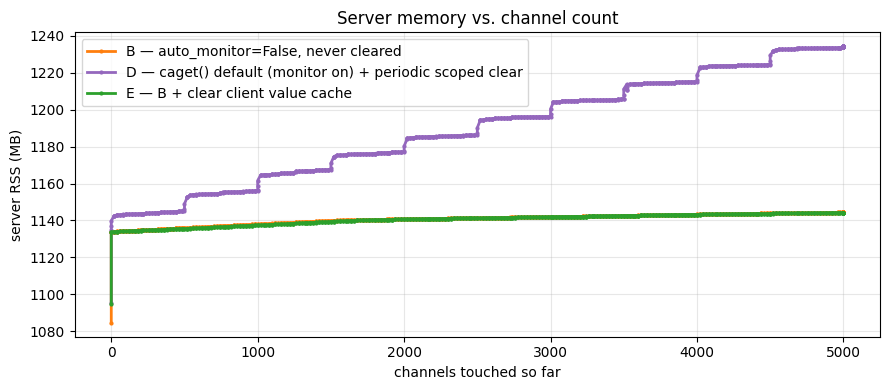

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
for label in LABEL_LIST:
    df = mem[label]
    ax.plot(df["channels_touched_so_far"], df["server_mem_rss_mb"], label=LABELS[label], color=COLORS[label], lw=2, marker="o", ms=2)
ax.set_xlabel("channels touched so far")
ax.set_ylabel("server RSS (MB)")
ax.set_title("Server memory vs. channel count")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

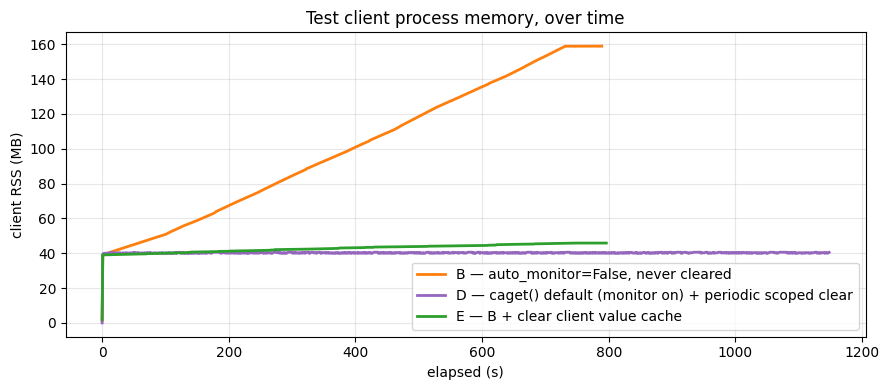

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
for label in LABEL_LIST:
    df = mem[label]
    ax.plot(df["elapsed_s"], df["client_mem_rss_mb"], label=LABELS[label], color=COLORS[label], lw=2)
ax.set_xlabel("elapsed (s)")
ax.set_ylabel("client RSS (MB)")
ax.set_title("Test client process memory, over time")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

## Round duration (performance)

In [7]:
def summarize_rounds(label, df):
    d = df["round_dur_s"].dropna()
    first10 = d.iloc[:10].mean()
    last10 = d.iloc[-10:].mean()
    trend = "growing" if last10 > first10 * 1.1 else "shrinking" if last10 < first10 * 0.9 else "flat"
    return {
        "scenario": LABELS[label],
        "n_rounds": len(d),
        "mean_s": round(d.mean(), 3),
        "median_s": round(d.median(), 3),
        "p95_s": round(d.quantile(0.95), 3),
        "first10_avg_s": round(first10, 3),
        "last10_avg_s": round(last10, 3),
        "trend": trend,
    }

round_summary = pd.DataFrame([summarize_rounds(label, rounds[label]) for label in LABEL_LIST]).set_index("scenario")
round_summary

,n_rounds,mean_s,median_s,p95_s,first10_avg_s,last10_avg_s,trend
scenario,,,,,,,
"B — auto_monitor=False, never cleared",300,2.331,2.476,3.745,3.661,0.713,shrinking
D — caget() default (monitor on) + periodic scoped clear,300,3.528,3.508,3.834,3.441,3.649,flat
E — B + clear client value cache,300,2.353,2.523,3.652,2.283,0.653,shrinking


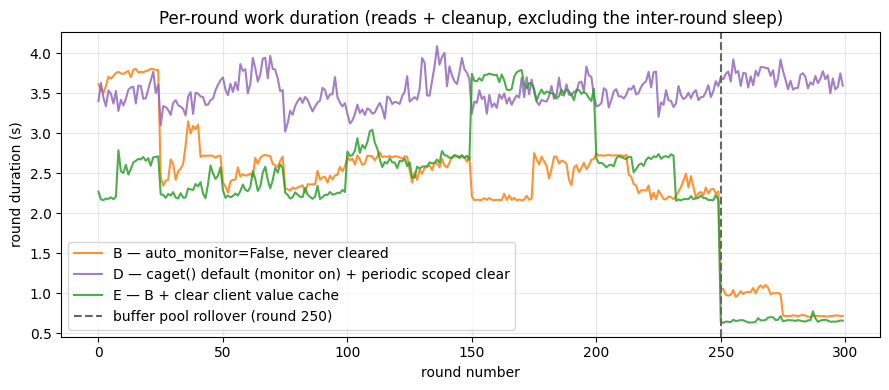

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for label in LABEL_LIST:
    df = rounds[label]
    ax.plot(df["round_num"], df["round_dur_s"], label=LABELS[label], color=COLORS[label], lw=1.5, alpha=0.85)
# Buffer-pool rollover: round_num == total_buffers is where round_num % n_buffers
# starts repeating already-touched buffer numbers -- e.g. a scenario that never
# clears its channels (B, E) gets to hit its own channel cache from here on,
# instead of paying for a fresh CA connect every round. Same total_buffers for
# every scenario in this comparison (same --n-servers/--pvs-per-server config),
# so take it from any one of them. Column absent in data from before this was
# added to run_channel_cost_test.py -- skip the marker rather than fail.
some_df = rounds[LABEL_LIST[0]]
if "total_buffers" in some_df.columns:
    rollover = some_df["total_buffers"].iloc[0]
    ax.axvline(rollover, color="0.4", ls="--", lw=1.5, label=f"buffer pool rollover (round {rollover})")
ax.set_xlabel("round number")
ax.set_ylabel("round duration (s)")
ax.set_title("Per-round work duration (reads + cleanup, excluding the inter-round sleep)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

## Reading the result

- **Server memory**: B and E should land close together (both small and bounded) -- E's extra
  cache-clear step doesn't touch anything server-side. D should remain the highest, per the
  per-subscription backlog finding above.
- **Client memory**: this is the axis E specifically targets. If E's `client_kb_per_channel` is
  close to D's (small) rather than B's (large), clearing just the value cache is enough to avoid
  the growth -- without needing `clear_channel()`'s shared-channel risk.
- **Round duration**: if E's `mean_s`/`median_s` are close to B's, the extra cache-clear call costs
  essentially nothing -- E would then be a strictly better choice than B on memory, at no
  performance cost, and safer than C on shared-channel risk.
- **The dashed "buffer pool rollover" line** marks round_num == total_buffers, where buffer numbers
  start repeating. B and E (both leave the channel itself open) should show a sharp drop right at
  that line -- create_channel() hits its own cache for a name it's already opened earlier in the
  run instead of paying for a fresh CA connect. D (clears every round) should show no such drop.